# #1 — Target Data: Data ingestion & Schema Definition

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)

# --- File 1: Multi-station 2016-2020 (combined from individual year files) ---
files_2016_2020 = {
    '2016': '../../data/raw/air_quality/AirQualityDataDaily_2016.csv',
    '2017': '../../data/raw/air_quality/AirQualityDataDaily_2017.csv',
    '2018': '../../data/raw/air_quality/AirQualityDataDaily_2018.csv',
    '2019': '../../data/raw/air_quality/AirQualityDataDaily_2019.csv',
    '2020': '../../data/raw/air_quality/AirQualityDataDaily_2020.csv'
}

all_records_2016_2020 = []
for year, file_path in files_2016_2020.items():
    # Read header for station names from each file
    header_row = pd.read_csv(file_path, skiprows=3, nrows=1, header=None)
    station_names = header_row.iloc[0].tolist()

    raw_year_df = pd.read_csv(file_path, skiprows=11, header=None)

    col_idx = 1
    station_idx = 1
    while col_idx < raw_year_df.shape[1] - 1:
        sname = station_names[station_idx] if station_idx < len(station_names) else f'Station_{col_idx}'
        if pd.isna(sname) or str(sname).strip() == '':
            col_idx += 2; station_idx += 2; continue
        values = raw_year_df.iloc[:, col_idx]
        status = raw_year_df.iloc[:, col_idx + 1] if col_idx + 1 < raw_year_df.shape[1] else [None]*len(raw_year_df)
        for d, v, s in zip(raw_year_df.iloc[:, 0], values, status):
            all_records_2016_2020.append({'date': d, 'station': str(sname).strip(), 'pm25_raw': v, 'status_raw': s})
        col_idx += 2; station_idx += 2

df1 = pd.DataFrame(all_records_2016_2020)


# --- File 2: Single station 2020-2025 ---
df2 = pd.read_csv('../../data/raw/air_quality/AirQualityDataDaily2021_2025.csv', skiprows=11, header=None,
                  names=['date', 'pm25_raw', 'status_raw'])
df2['station'] = 'London Marylebone Road'
df2 = df2[['date', 'station', 'pm25_raw', 'status_raw']]

# Combine
df = pd.concat([df1, df2], ignore_index=True)

# --- Region schema (added for notebook flow; VERIFY these assignments) ---
station_to_region = {
    'Auchencorth Moss': 'Scotland',
    'Inverness': 'Scotland',
    'Bournemouth': 'South West',
    'Brighton Preston Park': 'South East',
    'Chilbolton Observatory': 'South East',
    'London Marylebone Road': 'London',
    'London N. Kensington': 'London',
    'London Westminster': 'London',
    'Northampton Kingsthorpe': 'East Midlands',
    'Wrexham': 'Wales',
}
df['region'] = df['station'].map(station_to_region)
_unmapped = sorted(df.loc[df['region'].isna(), 'station'].unique())
if _unmapped:
    print('WARNING: stations with no region mapping (add them above):', _unmapped)

print(f'Raw combined shape (before any parsing): {df.shape}')
df.head(10)

Raw combined shape (before any parsing): (10966, 5)


,date,station,pm25_raw,status_raw,region
0,2016-01-01,Auchencorth Moss,2.886,V ugm-3 (GRAV EMFAB),Scotland
1,2016-01-02,Auchencorth Moss,1.12,V ugm-3 (GRAV EMFAB),Scotland
2,2016-01-03,Auchencorth Moss,0.56,V ugm-3 (GRAV EMFAB),Scotland
3,2016-01-04,Auchencorth Moss,1.983,V ugm-3 (GRAV EMFAB),Scotland
4,2016-01-05,Auchencorth Moss,2.372,V ugm-3 (GRAV EMFAB),Scotland
5,2016-01-06,Auchencorth Moss,2.157,V ugm-3 (GRAV EMFAB),Scotland
6,2016-01-07,Auchencorth Moss,0.259,V ugm-3 (GRAV EMFAB),Scotland
7,2016-01-08,Auchencorth Moss,2.33,V ugm-3 (GRAV EMFAB),Scotland
8,2016-01-09,Auchencorth Moss,2.417,V ugm-3 (GRAV EMFAB),Scotland
9,2016-01-10,Auchencorth Moss,-0.086,V ugm-3 (GRAV EMFAB),Scotland


# #3 — Target Data: Timestamp normalisation

In [5]:
#show the different date formats in the CSV's
print('Unique date formats in the raw CSVs:')
raw_dates1 = pd.read_csv('../../data/raw/air_quality/AirQualityDataDaily2016_2020.csv', skiprows=11, usecols=[0], header=None, nrows=1000)
raw_dates2 = pd.read_csv('../../data/raw/air_quality/AirQualityDataDaily2021_2025.csv', skiprows=11, usecols=[0], header=None, nrows=1000)
unique_dates1 = raw_dates1[0].dropna().unique()
unique_dates2 = raw_dates2[0].dropna().unique()
print(f'File 1 (2016-2020) unique date formats: {unique_dates1}')
print(f'File 2 (2021-2025) unique date formats: {unique_dates2}')


Unique date formats in the raw CSVs:
File 1 (2016-2020) unique date formats: <ArrowStringArray>
['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04', '2016-01-05',
 '2016-01-06', '2016-01-07', '2016-01-08', '2016-01-09', '2016-01-10',
 ...
 '2018-09-17', '2018-09-18', '2018-09-19', '2018-09-20', '2018-09-21',
 '2018-09-22', '2018-09-23', '2018-09-24', '2018-09-25', '2018-09-26']
Length: 1000, dtype: str
File 2 (2021-2025) unique date formats: <ArrowStringArray>
['01/01/2021', '02/01/2021', '03/01/2021', '04/01/2021', '05/01/2021',
 '06/01/2021', '07/01/2021', '08/01/2021', '09/01/2021', '10/01/2021',
 ...
 '18/09/2023', '19/09/2023', '20/09/2023', '21/09/2023', '22/09/2023',
 '23/09/2023', '24/09/2023', '25/09/2023', '26/09/2023', '27/09/2023']
Length: 1000, dtype: str


There are various date formats in the raw CSVs, so we need to normalize them to a consistent format. This will help with data analysis and ensure that all timestamps are comparable, 

This will help during our time series modeling, as we can ensure that all timestamps are in a consistent format and can be easily compared across different stations and time periods. We can sort, resample, detect gaps, and perform other time-based operations more easily with a standardized timestamp format.

In [6]:
# Parse the 'date' column to datetime and normalize to midnight so the
# series is strictly day-resolution (any stray time-of-day is dropped).
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce').dt.normalize()
print(f'After parsing + normalizing dates, shape: {df.shape}')
print(df['date'].head())

After parsing + normalizing dates, shape: (10966, 5)
0   2016-01-01
1   2016-02-01
2   2016-03-01
3   2016-04-01
4   2016-05-01
Name: date, dtype: datetime64[us]


## Best station

We need non-interrupted time series data for our modeling, so we will select the station with the most complete data as our "best station". This will help us avoid issues with missing data and ensure that we have a reliable dataset for our analysis.

In [7]:
# get longest continuous date range for each station that has PM2.5 data (non-null values)

df_best = df.copy()
df_best['pm25_numeric'] = pd.to_numeric(df_best['pm25_raw'], errors='coerce')

station_ranges = {}

for station, group in df_best.groupby('station'):
    group = (
        group.loc[group['pm25_numeric'].notna() & group['date'].notna(), ['date']]
        .drop_duplicates()
        .sort_values('date')
        .reset_index(drop=True)
    )

    if group.empty:
        continue

    date_diffs = group['date'].diff().dt.days.fillna(1)
    run_id = (date_diffs != 1).cumsum()

    runs = group.groupby(run_id)['date'].agg(['min', 'max', 'count'])
    best_run = runs.loc[runs['count'].idxmax()]

    station_ranges[station] = {
        'start': best_run['min'],
        'end': best_run['max'],
        'length_days': int(best_run['count'])
    }

station_ranges_df = (
    pd.DataFrame.from_dict(station_ranges, orient='index')
    .reset_index()
    .rename(columns={'index': 'station'})
    .sort_values('length_days', ascending=False)
    .reset_index(drop=True)
)

print("Longest continuous date range per station with non-null PM2.5:")
print(station_ranges_df.to_string(index=False))

Longest continuous date range per station with non-null PM2.5:
                station      start        end  length_days
 London Marylebone Road 2025-01-11 2025-12-31          355
  Brighton Preston Park 2018-07-31 2018-12-30          153
Northampton Kingsthorpe 2016-02-20 2016-07-10          142
              Inverness 2016-04-03 2016-08-17          137
     London Westminster 2016-03-09 2016-06-22          106
                Wrexham 2017-01-01 2017-04-05           95
            Bournemouth 2016-03-15 2016-06-06           84
       Auchencorth Moss 2016-03-13 2016-04-10           29
   London N. Kensington 2016-01-13 2016-02-10           29
 Chilbolton Observatory 2016-07-13 2016-07-31           19


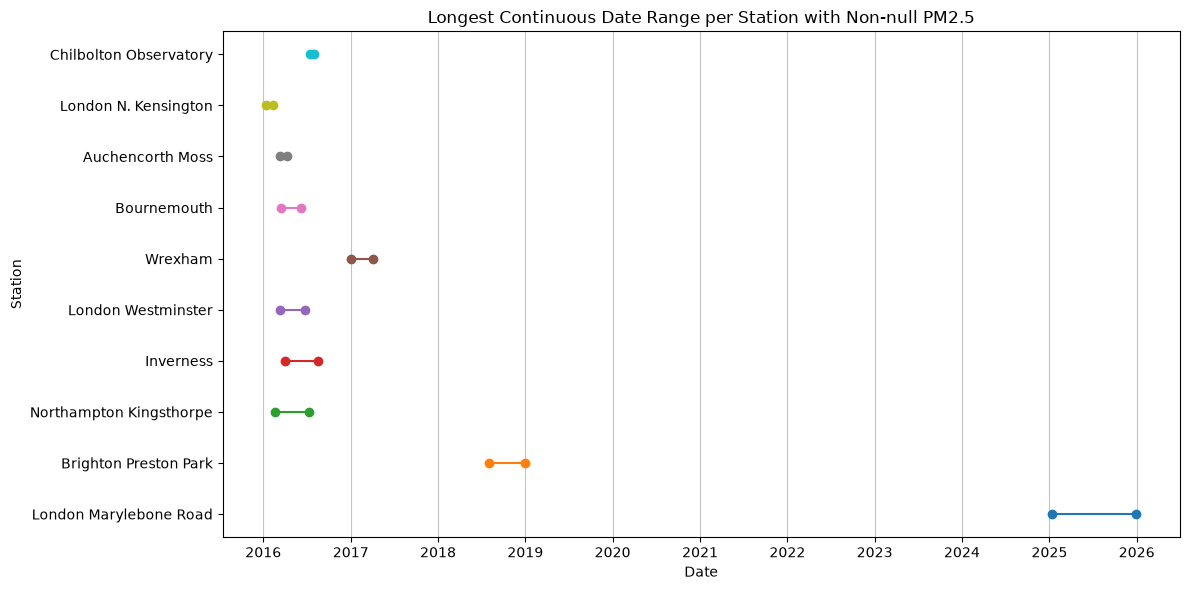

In [8]:
#plot the longest continuous date range for each station with non-null PM2.5
plt.figure(figsize=(12, 6))
for idx, row in station_ranges_df.iterrows():
    plt.plot([row['start'], row['end']], [idx, idx], marker='o', label=row['station'])
plt.yticks(range(len(station_ranges_df)), station_ranges_df['station'])
plt.xlabel('Date')
plt.ylabel('Station')
plt.title('Longest Continuous Date Range per Station with Non-null PM2.5')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()


London Marylebone Road is the station with the most complete data, so we will use this station as our "best station" for our analysis. We will filter the dataset to only include data from this station, and we will use this data for our time series modeling.

In [9]:
# drop all other stations expect London Marylebone Road, which has the most complete data
df = df[df['station'] == 'London Marylebone Road']

#after drop station column
df = df.drop(columns=['station','region'])

In [10]:
df.head()

,date,pm25_raw,status_raw
1830,2016-01-01,8.958,V ugm-3 (GRAV EMFAB)
1831,2016-02-01,5.649,V ugm-3 (GRAV EMFAB)
1832,2016-03-01,6.833,V ugm-3 (GRAV EMFAB)
1833,2016-04-01,9.916,V ugm-3 (GRAV EMFAB)
1834,2016-05-01,12.708,V ugm-3 (GRAV EMFAB)


## Data quality audit:

## 5. PM2.5 Value Profile
> Inspect raw PM2.5 values including non-numeric entries, value ranges, and distribution per station.

In [11]:
# Convert to numeric — non-numeric strings (e.g. 'No data') become NaN
df['pm25_numeric'] = pd.to_numeric(df['pm25_raw'], errors='coerce')

# Non-numeric raw values
non_numeric = df[df['pm25_numeric'].isna() & df['pm25_raw'].notna()]
print('--- Non-Numeric PM2.5 Raw Values ---')
print(non_numeric['pm25_raw'].value_counts().to_string())
print(f'\nTotal non-numeric PM2.5 entries: {len(non_numeric)}')

--- Non-Numeric PM2.5 Raw Values ---
pm25_raw
No data    277

Total non-numeric PM2.5 entries: 277


In [12]:
#drop pm25_raw column and rename pm25_numeric to pm25
df = df.drop(columns=['pm25_raw'])
df = df.rename(columns={'pm25_numeric': 'pm25'})

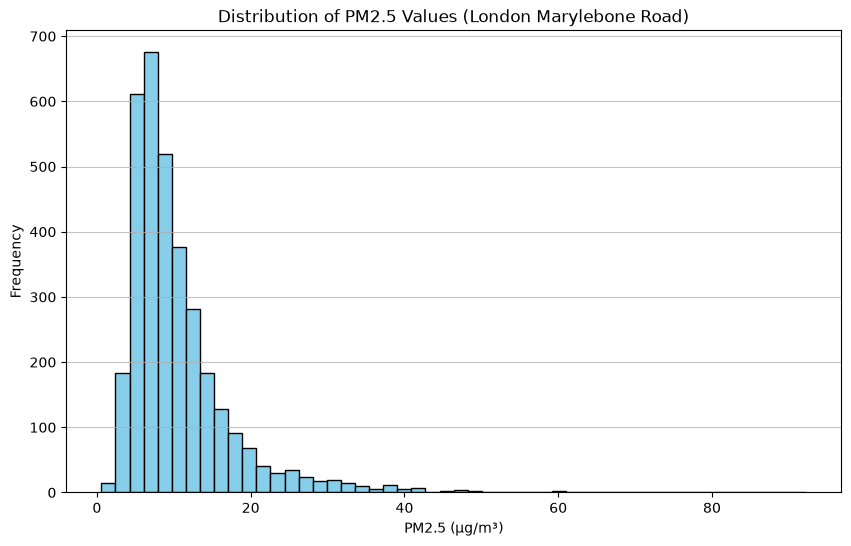

In [13]:
# Distribution plot of PM2.5 values
plt.figure(figsize=(10, 6))
plt.hist(df['pm25'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of PM2.5 Values (London Marylebone Road)')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


## 7. Duplicate Rows Profile
> Check for exact duplicate rows and duplicate (date, station) combinations.

In [14]:
# check for duplicates
exact_dupes = df.duplicated().sum()
date_station_dupes = df.duplicated(subset=['date', 'pm25']).sum()
print(f'Exact duplicate rows              : {exact_dupes}')
print(f'Duplicate (date) pairs   : {date_station_dupes}')
# print the duplicates if any
if date_station_dupes > 0:
    print('\nDuplicate (date) examples:')
    dupes = df[df.duplicated(subset=['date'], keep=False)]
    print(dupes[['date', 'pm25']].head(100000).to_string(index=False))


Exact duplicate rows              : 8
Duplicate (date) pairs   : 8

Duplicate (date) examples:
date  pm25
 NaT   NaN
 NaT   NaN
 NaT   NaN
 NaT   NaN
 NaT   NaN
 NaT   NaN
 NaT   NaN
 NaT   NaN
 NaT   NaN


## 8. Status Field — Cardinality & Distribution
> The status column indicates data verification level. Profile its unique values and frequency.

In [15]:
# Extract the single-letter status code from the raw status string
# e.g. 'V ugm-3 (GRAV EMFAB)' -> 'V'
df['status_code'] = df['status_raw'].astype(str).str.strip().str[0]

print('--- Status Code Cardinality (All Stations Combined) ---')
status_counts = df['status_code'].value_counts(dropna=False)
status_pct = (status_counts / len(df) * 100).round(2)
status_summary = pd.DataFrame({'count': status_counts, '%': status_pct})
print(status_summary.to_string())
print()
print('Key: V=Verified  P=Provisionally Verified  N=Not Verified  S=Suspect  nan=missing')
print(df['status_code'].value_counts().to_string())

--- Status Code Cardinality (All Stations Combined) ---
             count      %
status_code              
V             3648  99.75
NaN              9   0.25

Key: V=Verified  P=Provisionally Verified  N=Not Verified  S=Suspect  nan=missing
status_code
V    3648


## Missing data

In [16]:
#get gap date ranges for missing PM2.5 values (NA values)
missing_dates = df[df['pm25'].isna()]['date']
if not missing_dates.empty:
    missing_ranges = []
    start_date = None
    prev_date = None

    for current_date in missing_dates:
        if start_date is None:
            start_date = current_date
        elif prev_date is not None and (current_date - prev_date).days > 1:
            missing_ranges.append((start_date, prev_date))
            start_date = current_date
        prev_date = current_date

    if start_date is not None and prev_date is not None:
        missing_ranges.append((start_date, prev_date))

    print('--- Missing PM2.5 Date Ranges ---')
    for start, end in missing_ranges:
        print(f'{start.date()} to {end.date()} (length: {(end - start).days + 1} days)')

--- Missing PM2.5 Date Ranges ---
2016-11-02 to 2016-11-02 (length: 1 days)
2016-12-02 to 2016-02-16 (length: -289 days)
2016-12-07 to 2017-06-02 (length: 178 days)
2017-08-02 to 2017-08-02 (length: 1 days)
2017-09-02 to 2017-09-02 (length: 1 days)
2017-10-02 to 2017-10-02 (length: 1 days)
2017-10-05 to 2017-10-06 (length: 2 days)
2017-11-06 to 2017-11-06 (length: 1 days)
2017-12-06 to 2017-08-08 (length: -119 days)
2017-08-23 to 2017-06-09 (length: -74 days)
2017-07-09 to 2017-07-09 (length: 1 days)
2017-08-09 to 2017-08-09 (length: 1 days)
2017-09-09 to 2017-09-09 (length: 1 days)
2017-10-09 to 2017-10-09 (length: 1 days)
2017-11-09 to 2017-11-09 (length: 1 days)
2017-11-29 to 2018-02-02 (length: 66 days)
2018-06-05 to 2018-06-05 (length: 1 days)
2018-07-05 to 2018-07-05 (length: 1 days)
2018-08-05 to 2018-06-18 (length: -47 days)
2018-06-20 to 2018-02-07 (length: -132 days)
2018-03-07 to 2018-03-07 (length: 1 days)
2018-04-07 to 2018-04-07 (length: 1 days)
2018-08-07 to 2018-08-07 (

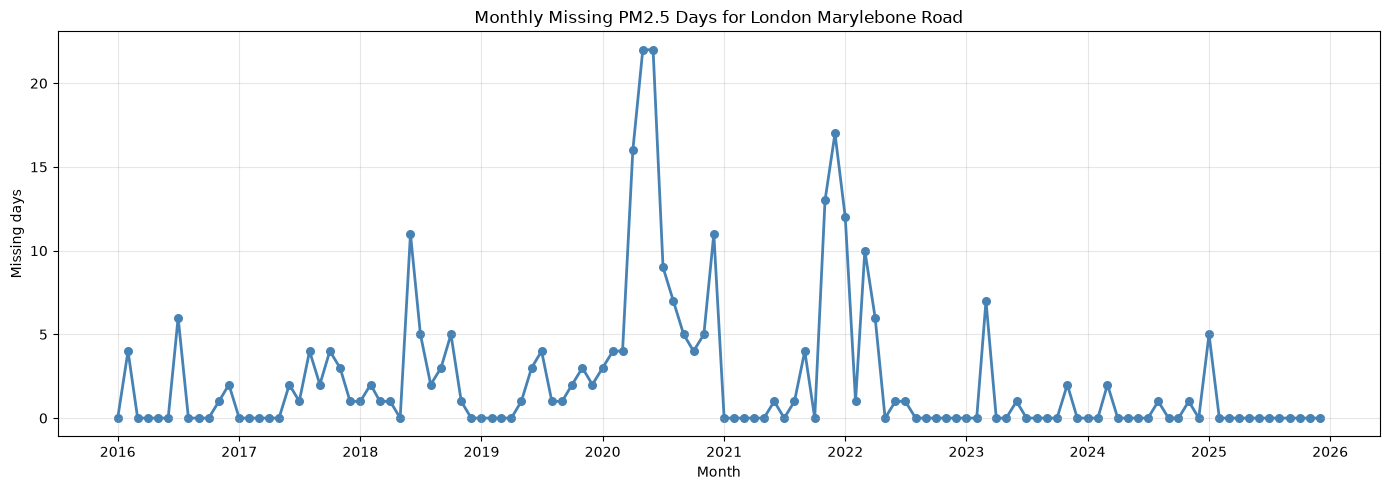

In [17]:
monthly_missing_days = (
    missing_dates.dt.to_period('M')
    .value_counts()
    .sort_index()
)
monthly_missing_days.index = monthly_missing_days.index.to_timestamp()

all_months = pd.date_range(
    df['date'].min().to_period('M').to_timestamp(),
    df['date'].max().to_period('M').to_timestamp(),
    freq='MS'
)
monthly_missing_days = monthly_missing_days.reindex(all_months, fill_value=0)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_missing_days.index,
    monthly_missing_days.values,
    linewidth=2,
    color='steelblue'
)
plt.scatter(
    monthly_missing_days.index,
    monthly_missing_days.values,
    color='steelblue',
    s=30
)
plt.title('Monthly Missing PM2.5 Days for London Marylebone Road')
plt.xlabel('Month')
plt.ylabel('Missing days')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

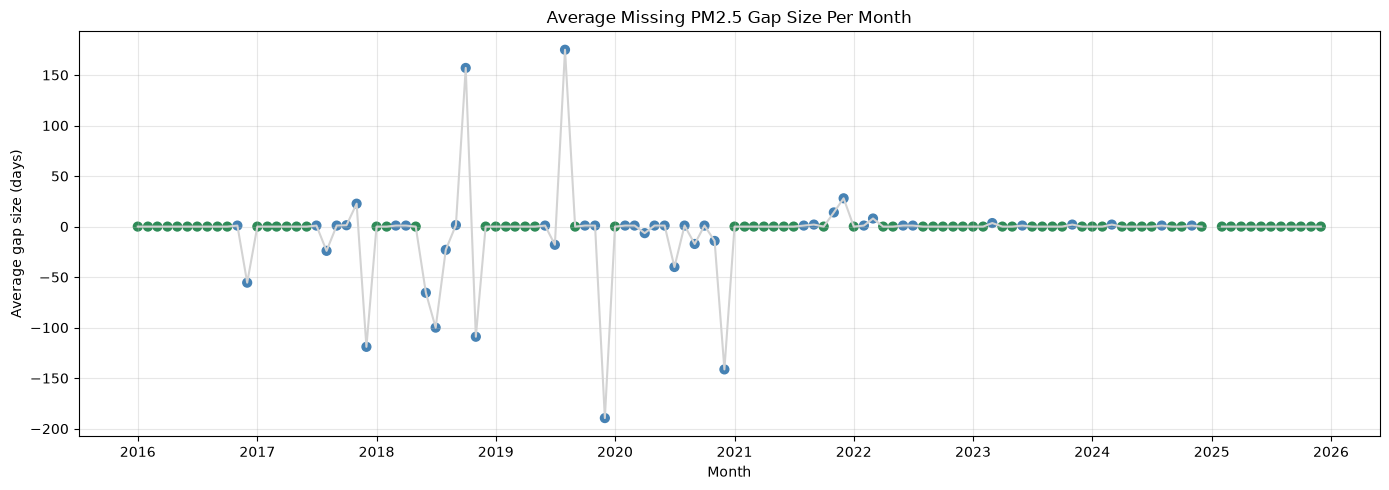

In [18]:
gap_df = pd.DataFrame(missing_ranges, columns=['start', 'end'])
gap_df['length_days'] = (gap_df['end'] - gap_df['start']).dt.days + 1
gap_df['month'] = gap_df['start'].dt.to_period('M').dt.to_timestamp()

monthly_avg_gap = gap_df.groupby('month')['length_days'].mean()

all_months = pd.date_range(
    df['date'].min().to_period('M').to_timestamp(),
    df['date'].max().to_period('M').to_timestamp(),
    freq='MS'
)
monthly_avg_gap = monthly_avg_gap.reindex(all_months, fill_value=0)

colors = ['seagreen' if value == 0 else 'steelblue' for value in monthly_avg_gap.values]

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg_gap.index, monthly_avg_gap.values, color='lightgray', linewidth=1.5)
plt.scatter(monthly_avg_gap.index, monthly_avg_gap.values, c=colors, s=40)

plt.title('Average Missing PM2.5 Gap Size Per Month')
plt.xlabel('Month')
plt.ylabel('Average gap size (days)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

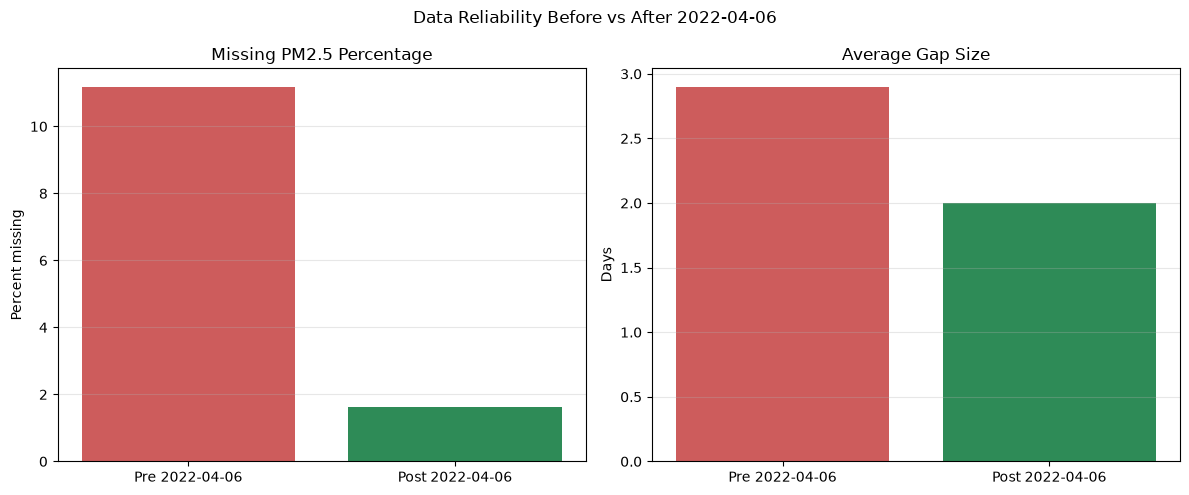

                 missing_pct  avg_gap_size
Pre 2022-04-06         11.17           2.9
Post 2022-04-06         1.61           2.0


In [19]:
cutoff = pd.Timestamp('2022-04-06')

pre = df[df['date'] < cutoff].copy()
post = df[df['date'] >= cutoff].copy()

def gap_summary(frame):
    missing_dates = frame.loc[frame['pm25'].isna(), 'date'].sort_values()

    gap_lengths = []
    if not missing_dates.empty:
        start_date = None
        prev_date = None

        for current_date in missing_dates:
            if start_date is None:
                start_date = current_date
            elif (current_date - prev_date).days > 1:
                gap_lengths.append((prev_date - start_date).days + 1)
                start_date = current_date
            prev_date = current_date

        gap_lengths.append((prev_date - start_date).days + 1)

    total_rows = len(frame)
    missing_rows = int(frame['pm25'].isna().sum())

    return {
        'missing_pct': 100 * missing_rows / total_rows if total_rows else 0,
        'avg_gap_size': np.mean(gap_lengths) if gap_lengths else 0,
    }

summary = pd.DataFrame(
    {
        'Pre 2022-04-06': gap_summary(pre),
        'Post 2022-04-06': gap_summary(post)
    }
).T

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(summary.index, summary['missing_pct'], color=['indianred', 'seagreen'])
axes[0].set_title('Missing PM2.5 Percentage')
axes[1].set_title('Average Gap Size')
axes[1].set_title('Mean Gap Length')
axes[0].set_ylabel('Percent missing')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(summary.index, summary['avg_gap_size'], color=['indianred', 'seagreen'])
axes[1].set_title('Average Gap Size')
axes[1].set_ylabel('Days')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Data Reliability Before vs After 2022-04-06')
plt.tight_layout()
plt.show()

print(summary.round(2))

In [20]:
pre_missing = summary.loc['Pre 2022-04-06', 'missing_pct']
post_missing = summary.loc['Post 2022-04-06', 'missing_pct']

pre_gap = summary.loc['Pre 2022-04-06', 'avg_gap_size']
post_gap = summary.loc['Post 2022-04-06', 'avg_gap_size']

# positive = improvement (lower missing rate / shorter gaps after cutoff)
missing_pct_improvement = ((pre_missing - post_missing) / pre_missing) * 100 if pre_missing != 0 else np.nan
gap_pct_improvement = ((pre_gap - post_gap) / pre_gap) * 100 if pre_gap != 0 else np.nan

print(f"Improvement in missing rate: {missing_pct_improvement:.2f}%")
print(f"Improvement in mean gap length: {gap_pct_improvement:.2f}%")

Improvement in missing rate: 85.59%
Improvement in mean gap length: 30.98%


In [21]:
#how many days after 2022-04-06 in total including missing values
total_days_after_cutoff = len(df[df['date'] >= cutoff])
print(f'Total days after 2022-04-06: {total_days_after_cutoff} days')

Total days after 2022-04-06: 1366 days


#### Data reliability:

After '2022-04-06' the data becomes far more reliable, with fewer missing values and more consistent readings. This is likely due to improvements in the monitoring equipment or data collection processes.

There are fewer missing values post '2022-04-06', with an 85.59% improvement in data completeness and a 30.98% improvement in the average size of missing data gaps. This indicates that the data is more reliable and can be used for analysis with greater confidence.

Choosing to drop data before '2022-04-06' is a reasonable decision, as it allows us to focus on the more reliable and complete data for our modeling and analysis. This will help us avoid issues with missing data and ensure that we have a more accurate representation of the PM2.5 levels in London.

In [22]:
#are there any gaps greater than 7 days after 2022-04-06
gaps_after_cutoff = gap_df[gap_df['start'] > cutoff]
gaps_gt_7_after_cutoff = gaps_after_cutoff[gaps_after_cutoff['length_days'] > 7]
if not gaps_gt_7_after_cutoff.empty:
    print('Gaps greater than 7 days after 2022-04-06:')
    print(gaps_gt_7_after_cutoff[['start', 'end', 'length_days']].to_string(index=False))
else:
    print('No gaps greater than 7 days after 2022-04-06.')

No gaps greater than 7 days after 2022-04-06.


In [23]:
#drop all data before 2022-04-06
cutoff = '2022-04-06'
df = df[df['date'] > cutoff].copy()
df = df.sort_values('date').reset_index(drop=True)


## Missing data gaps

#### Linear Interpolation for Short Gaps

For gaps between 1-2 days in the remaining data we will use Linear Interpolation to fill in the missing values. This method is appropriate for short gaps, as it assumes that the change between two known values is linear and can be estimated based on the surrounding data points. Which is a reasonable assumption for PM2.5 levels, as they tend to change gradually over time instead of abruptly.

Linear interpolation fills gaps by drawing a straight line between the two known values on either side of the gap and estimating the missing values based on that line. This method is simple and effective for short gaps, and it can help us maintain the continuity of the time series data.

#### Same-weekday Interpolation for Longer Gaps

For gaps longer than 2 days, we will use Same-weekday Interpolation to fill in the missing values. This method is appropriate for longer gaps, as it assumes that the PM2.5 levels on a given day of the week are similar to those on the same day of the previous week. This is a reasonable assumption, as PM2.5 levels can be influenced by factors such as traffic patterns and weather conditions, which tend to follow weekly cycles.

We will use the 4 previous same weekdays to fill in the missing values by creating a rolling mean of the PM2.5 values for the same day of the week over the previous 4 weeks. This will help us estimate the missing values based on the historical patterns of PM2.5 levels for that specific day of the week.

In [24]:
# missing values before interpolation
df['pm25_imputed'] = False
missing_before = df['pm25'].isna().sum()
print(f'Missing values before interpolation: {missing_before}')

Missing values before interpolation: 21


In [25]:
was_missing = df['pm25'].isna()
df['pm25'] = df['pm25'].interpolate(method='linear', limit=2, limit_area='inside')
df.loc[was_missing & df['pm25'].notna(), 'pm25_imputed'] = True

In [26]:
#missing values after linear interpolation
missing_after_linear = df['pm25'].isna().sum()
print(f'Missing values before linear interpolation: {missing_before}')
print(f'Missing values after linear interpolation: {missing_after_linear}')

Missing values before linear interpolation: 21
Missing values after linear interpolation: 6


Remaining missing values filled by same-weekday interpolation

In [27]:
was_missing = df['pm25'].isna()
df['pm25'] = df.groupby(df['date'].dt.dayofweek)['pm25'].transform(
    lambda s: s.fillna(s.rolling(4, min_periods=1).mean())
)
df.loc[was_missing & df['pm25'].notna(), 'pm25_imputed'] = True

In [28]:
#missing values after same-weekday interpolation
missing_after_weekday = df['pm25'].isna().sum()
print(f'Missing values after same-weekday interpolation: {missing_after_weekday}')

Missing values after same-weekday interpolation: 0


## Outliers

In [29]:
def detect_outliers(group):
    Q1 = group['pm25'].quantile(0.25)
    Q3 = group['pm25'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    # Domain rule: values above 150 µg/m³ are physically implausible for UK
    domain_upper = 150

    group = group.copy()
    group['iqr_outlier']    = (group['pm25'] < lower) | (group['pm25'] > upper) #outside the IQR range
    group['domain_outlier'] = group['pm25'] > domain_upper
    group['outlier']        = group['iqr_outlier'] | group['domain_outlier']
    group['iqr_lower']      = lower
    group['iqr_upper']      = upper
    return group

In [30]:
#run detect_outliers on the entire dataframe (since we only have one station now)
df = detect_outliers(df)

In [31]:
#print total outliers detected
total_outliers = df['outlier'].sum() # when outlier is True, it counts as 1
print(f'Total outliers detected: {total_outliers} ({(total_outliers / len(df) * 100).round(2)}%)')

Total outliers detected: 51 (3.74%)


In [32]:
#domain outliers
domain_outliers = df['domain_outlier'].sum()
print(f'Total domain outliers detected: {domain_outliers} ({(domain_outliers / len(df) * 100).round(2)}%)')

Total domain outliers detected: 0 (0.0%)


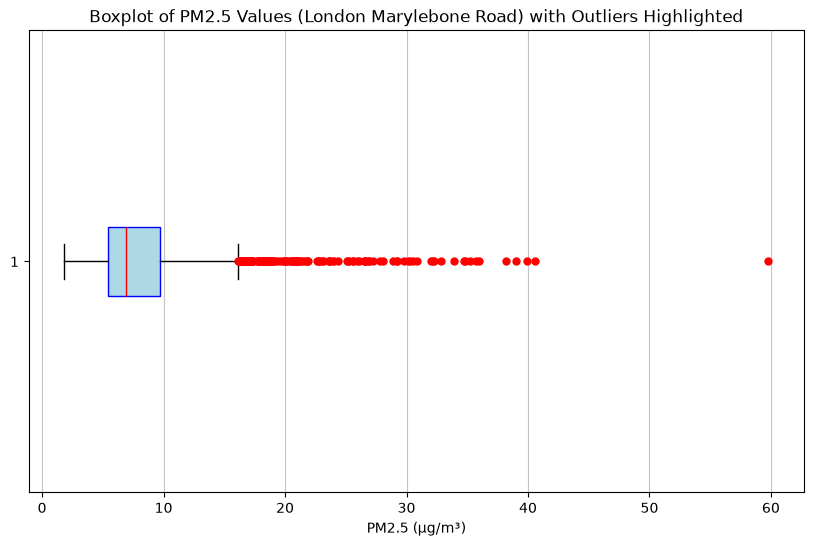

In [33]:
#create boxplot of PM2.5 values with outliers highlighted
plt.figure(figsize=(10, 6))
plt.boxplot(df['pm25'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none', markeredgecolor='red'))
plt.title('Boxplot of PM2.5 Values (London Marylebone Road) with Outliers Highlighted')
plt.xlabel('PM2.5 (µg/m³)')
plt.grid(axis='x', alpha=0.75)
plt.show()

## Step 7: Outlier Treatment
- **Domain outliers (>150 µg/m³)** → cap at 150 (physically implausible for UK)
- **IQR outliers** → flag only, keep original value (could be real events e.g. Saharan dust, Bonfire Night)
- **Suspect status (S)** → flag but keep

In [34]:
df['pm25'] = df['pm25'].copy()
df.loc[df['domain_outlier'], 'pm25'] = 150 

print(f'Domain outliers capped at 150 µg/m³ : {df["domain_outlier"].sum()}')
print(f'IQR outliers flagged (values kept)   : {df["iqr_outlier"].sum()}')

Domain outliers capped at 150 µg/m³ : 0
IQR outliers flagged (values kept)   : 51


## Head check

In [35]:
df.head()

,date,status_raw,pm25,status_code,pm25_imputed,iqr_outlier,domain_outlier,outlier,iqr_lower,iqr_upper
0,2022-04-07,V ugm-3 (GRAV EMFAB),5.53,V,False,False,False,False,-7.5,22.6
1,2022-04-08,V ugm-3 (GRAV EMFAB),6.72,V,False,False,False,False,-7.5,22.6
2,2022-04-09,V ugm-3 (GRAV EMFAB),5.62,V,False,False,False,False,-7.5,22.6
3,2022-04-10,V ugm-3 (GRAV EMFAB),8.36,V,False,False,False,False,-7.5,22.6
4,2022-04-11,V ugm-3 (GRAV EMFAB),15.90,V,False,False,False,False,-7.5,22.6


## Status Code check

All of our remaining data readings for the London Marylebone Road station have a status code of 'V', which indicates that the data has been verified and is considered reliable by UK-AIR / DEFRA. This is a positive outcome, as it suggests that the data we are working with is of high quality and can be used for our analysis with confidence.

In [36]:
#check the status codes after cleaning
status_counts_after = df['status_code'].value_counts(dropna=False)
status_pct_after = (status_counts_after / len(df) * 100).round(2)
status_summary_after = pd.DataFrame({'count': status_counts_after, '%': status_pct_after})
print('--- Status Code Cardinality After Cleaning ---')
print(status_summary_after.to_string())

--- Status Code Cardinality After Cleaning ---
             count      %
status_code              
V             1365  100.0


## Dataset size and general statistics

In [37]:
# dataset coverage
full_index = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
expected_days = len(full_index)
observed_days = df['date'].nunique()
missing_slots = expected_days - observed_days

date_diffs = df['date'].sort_values().diff().dt.days.fillna(1)
streak_id = (date_diffs != 1).cumsum()
longest_streak = df.groupby(streak_id)['date'].count().max()

print('--- Dataset Coverage ---')
print(f'Date range             : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Total rows             : {len(df):,}')
print(f'Expected calendar days : {expected_days:,}')
print(f'Missing date slots     : {missing_slots:,}')
print(f'Calendar completeness  : {observed_days / expected_days * 100:.2f}%')
print(f'Longest continuous run : {longest_streak:,} days')

--- Dataset Coverage ---
Date range             : 2022-04-07 to 2025-12-31
Total rows             : 1,365
Expected calendar days : 1,365
Missing date slots     : 0
Calendar completeness  : 100.00%
Longest continuous run : 1,365 days


In [38]:
# PM2.5 completeness after imputation
print('--- PM2.5 Completeness ---')
print(f'Non-null PM2.5         : {df["pm25"].notna().sum():,} ({df["pm25"].notna().mean() * 100:.2f}%)')
print(f'Missing PM2.5          : {df["pm25"].isna().sum():,}')
print(f'Imputed PM2.5          : {df["pm25_imputed"].sum():,} ({df["pm25_imputed"].mean() * 100:.2f}%)')
print(f'Measured PM2.5         : {(~df["pm25_imputed"]).sum():,}')

--- PM2.5 Completeness ---
Non-null PM2.5         : 1,365 (100.00%)
Missing PM2.5          : 0
Imputed PM2.5          : 21 (1.54%)
Measured PM2.5         : 1,344


In [39]:
# PM2.5 distribution
print('--- PM2.5 Distribution (all values, µg/m³) ---')
print(df['pm25'].describe(percentiles=[0.25, 0.5, 0.75]).round(3).to_string())

print('\n--- PM2.5 Distribution (measured only, µg/m³) ---')
print(df.loc[~df['pm25_imputed'], 'pm25'].describe(percentiles=[0.25, 0.5, 0.75]).round(3).to_string())

--- PM2.5 Distribution (all values, µg/m³) ---
count    1365.000
mean        8.686
std         5.667
min         1.800
25%         5.400
50%         6.900
75%         9.700
max        59.800

--- PM2.5 Distribution (measured only, µg/m³) ---
count    1344.000
mean        8.669
std         5.681
min         1.800
25%         5.400
50%         6.830
75%         9.628
max        59.800


In [40]:
# outlier summary
print('--- Outliers (flagged, not removed) ---')
print(f'IQR outliers           : {df["iqr_outlier"].sum():,} ({df["iqr_outlier"].mean() * 100:.2f}%)')
print(f'Domain outliers >150   : {df["domain_outlier"].sum():,}')
print(f'Any outlier flag       : {df["outlier"].sum():,}')

--- Outliers (flagged, not removed) ---
IQR outliers           : 51 (3.74%)
Domain outliers >150   : 0
Any outlier flag       : 51


In [41]:
# monthly completeness
monthly = (
    df.set_index('date')
      .resample('MS')
      .agg(rows=('pm25', 'size'), imputed=('pm25_imputed', 'sum'))
)
monthly['measured'] = monthly['rows'] - monthly['imputed']
monthly['pct_measured'] = (monthly['measured'] / monthly['rows'] * 100).round(1)

print('--- Monthly Completeness ---')
print(monthly.to_string())

--- Monthly Completeness ---
            rows  imputed  measured  pct_measured
date                                             
2022-04-01    24        0        24         100.0
2022-05-01    31        0        31         100.0
2022-06-01    30        1        29          96.7
2022-07-01    31        1        30          96.8
2022-08-01    31        0        31         100.0
2022-09-01    30        0        30         100.0
2022-10-01    31        0        31         100.0
2022-11-01    30        0        30         100.0
2022-12-01    31        0        31         100.0
2023-01-01    31        0        31         100.0
2023-02-01    28        0        28         100.0
2023-03-01    31        7        24          77.4
2023-04-01    30        0        30         100.0
2023-05-01    31        0        31         100.0
2023-06-01    30        1        29          96.7
2023-07-01    31        0        31         100.0
2023-08-01    31        0        31         100.0
2023-09-01    30     

In [42]:
#export date and PM2.5 values to CSV for use in the next stage of analysis if they are complete (no missing values)
if df['pm25'].isna().sum() == 0 and df['date'].isna().sum() == 0:
    out = Path('../../data/processed/cleaned_london_marylebone_pm25.csv')
    out.parent.mkdir(parents=True, exist_ok=True)
    df[['date', 'pm25']].to_csv(out, index=False)
    print(f'Exported cleaned PM2.5 data to {out}')

Exported cleaned PM2.5 data to features/feature_data/cleaned_london_marylebone_pm25.csv


In [43]:
#export full dataset with imputation and outlier flags for reference
full_out = Path('../../data/processed/cleaned_london_marylebone_pm25_full.csv')
df.to_csv(full_out, index=False)
print(f'Exported full cleaned dataset to {full_out} (includes imputation and outlier flags)')

Exported full cleaned dataset to features/feature_data/cleaned_london_marylebone_pm25_full.csv (includes imputation and outlier flags)
